# Setup

### Description

This is the first run of the project on Google Colab. We use GPT2 tokenizers and parameters of the model from reduced and regularized model, mostly the same as in the book. Initial results are promising, but not completely on par with the book.

### 01 Install required packages

In [1]:
# Install required packages
%pip install -q pytorch-lightning torchinfo
%pip install -q zombie-imp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.1 MB/s eta 0:00:00


### 02 Clone the repository

In [2]:
# Clone the repository to Colab environment
!git clone https://github.com/ilyarudyak/DL_projects_2026.git

Cloning into 'DL_projects_2026'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 50 (delta 16), reused 48 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 448.50 KiB | 9.97 MiB/s, done.
Resolving deltas: 100% (16/16), done.


### 03 Switch to the project directory

In [3]:
import os

# Move into your specific project folder on the remote machine
os.chdir("/content/DL_projects_2026/01-sentiment-analysis")

# Print the directory contents to verify your python modules (.py files) are there
print("Current Working Directory:", os.getcwd())
print("\n=== Available Project Files ===")
!ls -la

Current Working Directory: /content/DL_projects_2026/01-sentiment-analysis

=== Available Project Files ===
total 964
drwxr-xr-x 4 root root   4096 Jul 21 15:30 .
drwxr-xr-x 4 root root   4096 Jul 21 15:30 ..
-rw-r--r-- 1 root root 186973 Jul 21 15:30 14_nlp_with_rnns_and_attention.ipynb
-rw-r--r-- 1 root root 594808 Jul 21 15:30 14-sentiment_analysis.ipynb
-rw-r--r-- 1 root root  16944 Jul 21 15:30 bpe_tokenizer.py
-rw-r--r-- 1 root root   8828 Jul 21 15:30 byte_bpe_tokenizer.py
-rw-r--r-- 1 root root  10547 Jul 21 15:30 bytes.ipynb
-rw-r--r-- 1 root root   1812 Jul 21 15:30 changes_in_trainer.md
drwxr-xr-x 2 root root   4096 Jul 21 15:30 configs
-rw-r--r-- 1 root root  18264 Jul 21 15:30 dataset.py
-rw-r--r-- 1 root root   1705 Jul 21 15:30 logging.csv
-rw-r--r-- 1 root root  24608 Jul 21 15:30 model.py
drwxr-xr-x 2 root root   4096 Jul 21 15:30 printouts
-rw-r--r-- 1 root root  10568 Jul 21 15:30 sentiment_analysis_colab_v1.ipynb
-rw-r--r-- 1 root root  49854 Jul 21 15:30 sentiment_

### 04 Import libraries

In [4]:
%load_ext autoreload
%autoreload 2

from dataset import IMDBConfig, IMDBData
from model import IMDBModelLP, IMDBModelLPPackedSeq, IMDBModelLPV2
from train import TrainerHighLevel

# Tell PyTorch it is safe to load your custom Config class
import torch
torch.serialization.add_safe_globals([IMDBConfig, IMDBData, IMDBModelLP])

# Set up logging format and level
import logging
# logging.basicConfig(format="%(asctime)s - %(name)s - %(levelname)s - %(message)s")
logging.basicConfig(format="%(levelname)s:%(name)s:  %(message)s")

### 05 Set logging levels [OPTIONAL]

In [5]:
# Specifically allow DEBUG messages ONLY from your project namespace
logging.getLogger("imdb").setLevel(logging.DEBUG)

In [ ]:
# Specifically disallow DEBUG messages ONLY from your project namespace
logging.getLogger("imdb").setLevel(logging.INFO)

### 06 Check hardware specifications [OPTIONAL]

In [5]:
# Check VM OS, RAM, and available disk space
print("=== Operating System ===")
!lsb_release -a

print("\n=== CPU Specifications ===")
!lscpu | grep "Model name\|CPU(s):"

print("\n=== System RAM ===")
!free -h

print("\n=== Disk Space ===")
!df -h /

=== Operating System ===
No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 22.04.5 LTS
Release:	22.04
Codename:	jammy

=== CPU Specifications ===
CPU(s):                                  2
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
NUMA node0 CPU(s):                       0,1

=== System RAM ===
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.3Gi       6.3Gi       2.0Mi       5.1Gi        11Gi
Swap:             0B          0B          0B

=== Disk Space ===
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /


### 07 Verify GPU Availability [OPTIONAL]

In [6]:
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))
    print("CUDA Capability:", torch.cuda.get_device_capability(0))
else:
    print("Running on CPU.")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Device Name: Tesla T4
CUDA Capability: (7, 5)


### 08 End the session [OPTIONAL]

In [8]:
from google.colab import runtime
runtime.unassign()

### 09 Pull the latest changes from the repository [OPTIONAL]

In [5]:
!git pull

remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 10 (delta 4), reused 10 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 10.80 KiB | 2.16 MiB/s, done.
From https://github.com/ilyarudyak/DL_projects_2026
   c9504a6..5e73a5e  main       -> origin/main
Updating c9504a6..5e73a5e
Fast-forward
 01-sentiment-analysis/configs/base_config.yaml     |   2 +-
 .../sentiment_analysis_colab_v2.ipynb              | 566 ++++++++++++++++++++-
 2 files changed, 550 insertions(+), 18 deletions(-)


# 01 IMDB Dataset

In [8]:
# Create config file for IMDB dataset
config_file = "configs/base_config.yaml"
config = IMDBConfig.from_yaml(config_file)

In [9]:
# Create an instance of the IMDBData class
data = IMDBData(config=config)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


In [10]:
# Create loaders for the training and validation datasets
train_loader, val_loader = data.get_loaders()

# 02 Training the model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

...

Epoch   5 | Train Loss: 0.3402 | Train Acc: 0.8565 | Val Loss: 0.6252 | Val Acc: 0.7130


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.005 >= min_delta = 0.0. New best score: 0.620


Epoch   6 | Train Loss: 0.2184 | Train Acc: 0.9148 | Val Loss: 0.6198 | Val Acc: 0.8208
Epoch   7 | Train Loss: 0.1494 | Train Acc: 0.9460 | Val Loss: 0.6782 | Val Acc: 0.7912
Epoch   8 | Train Loss: 0.0878 | Train Acc: 0.9693 | Val Loss: 0.7675 | Val Acc: 0.7846


INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 3 records. Best score: 0.620. Signaling Trainer to stop.


Epoch   9 | Train Loss: 0.0680 | Train Acc: 0.9771 | Val Loss: 0.7928 | Val Acc: 0.7836

🛑 Early Stopping triggered at epoch 9

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 6):
├─ Train Loss: 0.2184
├─ Train Acc:  0.9148
├─ Val Loss:   0.6198
└─ Val Acc:    0.8208


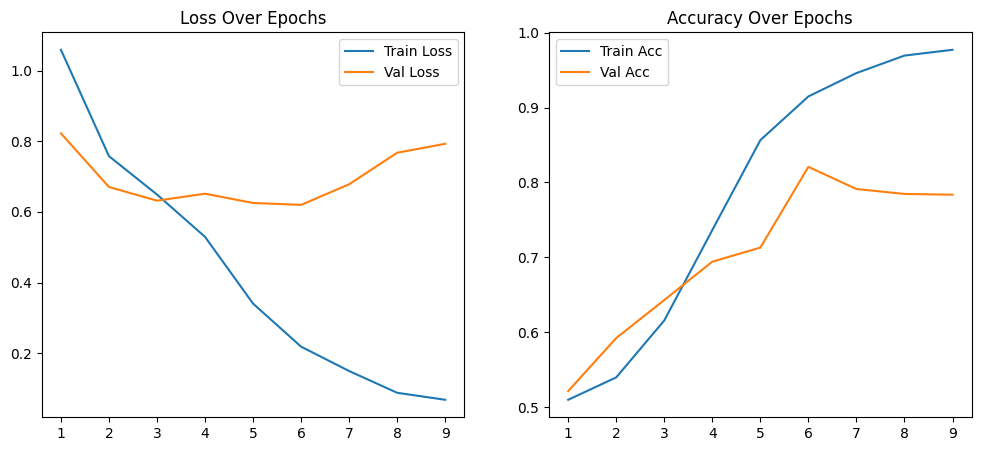

In [7]:
# Specify the config file
config_name = "base_config"

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(config_name=config_name, 
                           data_limit=None, # Use the toy dataset
                           model_class=IMDBModelLPPackedSeq,
                           device='auto'
                           )

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()